In [3]:
# ── ReviewGuard — Phase 1 EDA Notebook ───────────────────────────────────────
# Exploratory Data Analysis on our merged 372k review dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"]      = 12

print("✅ Libraries loaded!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ Libraries loaded!
   pandas  : 2.3.3
   numpy   : 2.3.5


In [4]:
# ── Load the Master Dataset ───────────────────────────────────────────────────

# Move to project root if running from notebooks folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

df = pd.read_csv("data/processed/reviews_cleaned.csv", low_memory=False)

print("✅ Dataset loaded successfully!")
print(f"\n{'='*45}")
print(f"  Total reviews     : {len(df):,}")
print(f"  Total columns     : {len(df.columns)}")
print(f"  Unique products   : {df['product_id'].nunique():,}")
print(f"  Unique reviewers  : {df['reviewer_id'].nunique():,}")
print(f"  Average rating    : {df['rating'].mean():.2f} ⭐")
print(f"{'='*45}")

✅ Dataset loaded successfully!

  Total reviews     : 372,598
  Total columns     : 16
  Unique products   : 5,798
  Unique reviewers  : 368,411
  Average rating    : 3.86 ⭐


In [5]:
# ── First Look at the Data ────────────────────────────────────────────────────

print("📊 Column Info:")
print("-" * 45)
for col in df.columns:
    dtype    = df[col].dtype
    missing  = df[col].isna().sum()
    print(f"  {col:<25} {str(dtype):<10} missing: {missing:,}")

print("\n📊 First 3 rows:")
df.head(3)

📊 Column Info:
---------------------------------------------
  product_id                object     missing: 0
  product_name              object     missing: 0
  reviewer_id               object     missing: 0
  reviewer_name             object     missing: 0
  rating                    int64      missing: 0
  review_date               object     missing: 0
  review_text               object     missing: 0
  review_title              object     missing: 0
  verified_purchase         object     missing: 0
  helpful_votes             int64      missing: 0
  category                  object     missing: 0
  price                     float64    missing: 39,651
  source_dataset            object     missing: 0
  is_duplicate_text         int64      missing: 0
  review_length             int64      missing: 0
  is_short_review           int64      missing: 0

📊 First 3 rows:


,product_id,product_name,reviewer_id,reviewer_name,rating,review_date,review_text,review_title,verified_purchase,helpful_votes,category,price,source_dataset,is_duplicate_text,review_length,is_short_review
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...",4,2023-01-01,Looks durable Charging is fine tooNo complains...,"Satisfied,Charging is really fast,Value for mo...",Unknown,0,Computers&Accessories|Accessories&Peripherals|...,399.0,amazon1,1,483,0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...",4,2023-01-01,I ordered this cable to connect my phone to An...,"A Good Braided Cable for Your Type C Device,Go...",Unknown,0,Computers&Accessories|Accessories&Peripherals|...,199.0,amazon1,1,1186,0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...",4,2023-01-01,"Not quite durable and sturdy,https://m.media-a...","Good speed for earlier versions,Good Product,W...",Unknown,0,Computers&Accessories|Accessories&Peripherals|...,199.0,amazon1,0,271,0


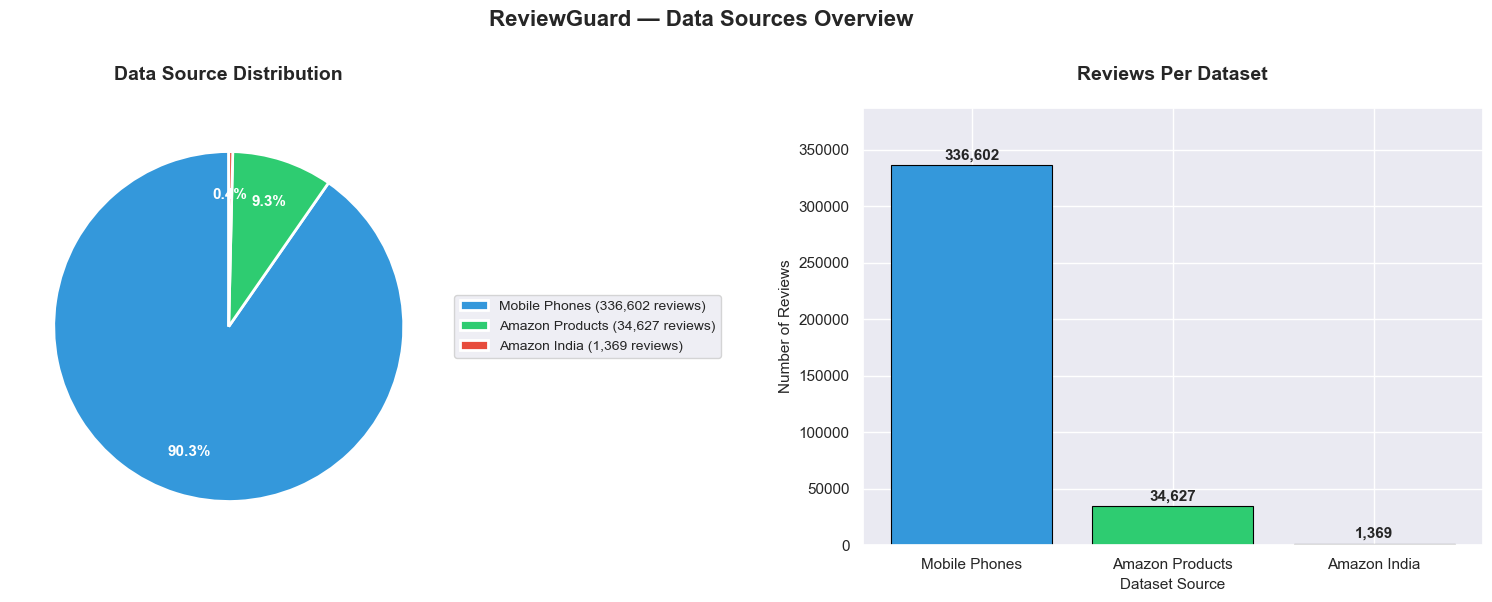

✅ Chart saved: outputs/charts/01_data_sources.png


In [15]:
# ── CHART 1: Dataset Source Breakdown ────────────────────────────────────────

source_counts = df["source_dataset"].value_counts()

# Simpler labels
source_labels = {
    "amazon1": "Amazon India",
    "amazon2": "Amazon Products",
    "amazon3": "Mobile Phones"
}

# Get clean labels for each source
clean_labels = [source_labels.get(s, s) for s in source_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── PIE CHART (left side) ────────────────────────────────────────────────────
colors = ["#3498db", "#2ecc71", "#e74c3c"]

# Only show percentage on the pie, put labels in legend
wedges, texts, autotexts = axes[0].pie(
    source_counts.values,
    labels=None,                     # No labels on pie itself
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75
)

# Make percentage text white and bold for readability
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(11)

axes[0].set_title("Data Source Distribution", 
                   fontsize=14, fontweight="bold", pad=20)

# Add a clean legend on the side
legend_labels = [
    f"{clean_labels[i]} ({source_counts.values[i]:,} reviews)"
    for i in range(len(source_counts))
]
axes[0].legend(
    wedges, 
    legend_labels, 
    loc="center left", 
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=10
)

# ── BAR CHART (right side) ───────────────────────────────────────────────────
bars = axes[1].bar(
    clean_labels,
    source_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)
axes[1].set_title("Reviews Per Dataset", fontsize=14, fontweight="bold", pad=20)
axes[1].set_ylabel("Number of Reviews", fontsize=11)
axes[1].set_xlabel("Dataset Source", fontsize=11)

# Add value labels on top of each bar
for bar, val in zip(bars, source_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5000,
        f"{val:,}",
        ha="center",
        fontweight="bold",
        fontsize=11
    )

# Give some headroom on top
axes[1].set_ylim(0, max(source_counts.values) * 1.15)

plt.suptitle("ReviewGuard — Data Sources Overview",
             fontsize=16, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("outputs/charts/01_data_sources.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved: outputs/charts/01_data_sources.png")

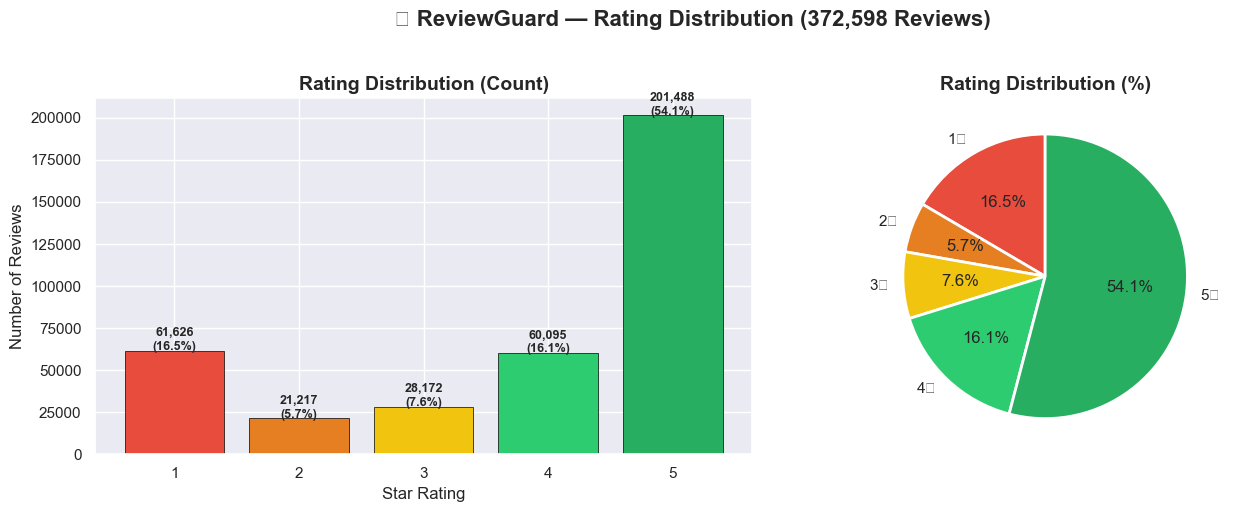

✅ Chart saved: outputs/charts/02_rating_distribution.png

📊 Key Insight:
   54.1% of reviews are 5-star — suspiciously high!
   This is a strong signal of possible fake review inflation.


In [9]:
# ── CHART 2: Rating Distribution ─────────────────────────────────────────────

rating_counts = df["rating"].value_counts().sort_index()
colors_rating = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color=colors_rating,
    edgecolor="black",
    linewidth=0.5
)
axes[0].set_title("Rating Distribution (Count)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")
for bar, val in zip(bars, rating_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f"{val:,}\n({val/len(df)*100:.1f}%)",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Pie chart
axes[1].pie(
    rating_counts.values,
    labels=[f"{r}★" for r in rating_counts.index],
    autopct="%1.1f%%",
    colors=colors_rating,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Rating Distribution (%)", fontsize=14, fontweight="bold")

plt.suptitle("⭐ ReviewGuard — Rating Distribution (372,598 Reviews)",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/charts/02_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved: outputs/charts/02_rating_distribution.png")
print(f"\n📊 Key Insight:")
print(f"   54.1% of reviews are 5-star — suspiciously high!")
print(f"   This is a strong signal of possible fake review inflation.")

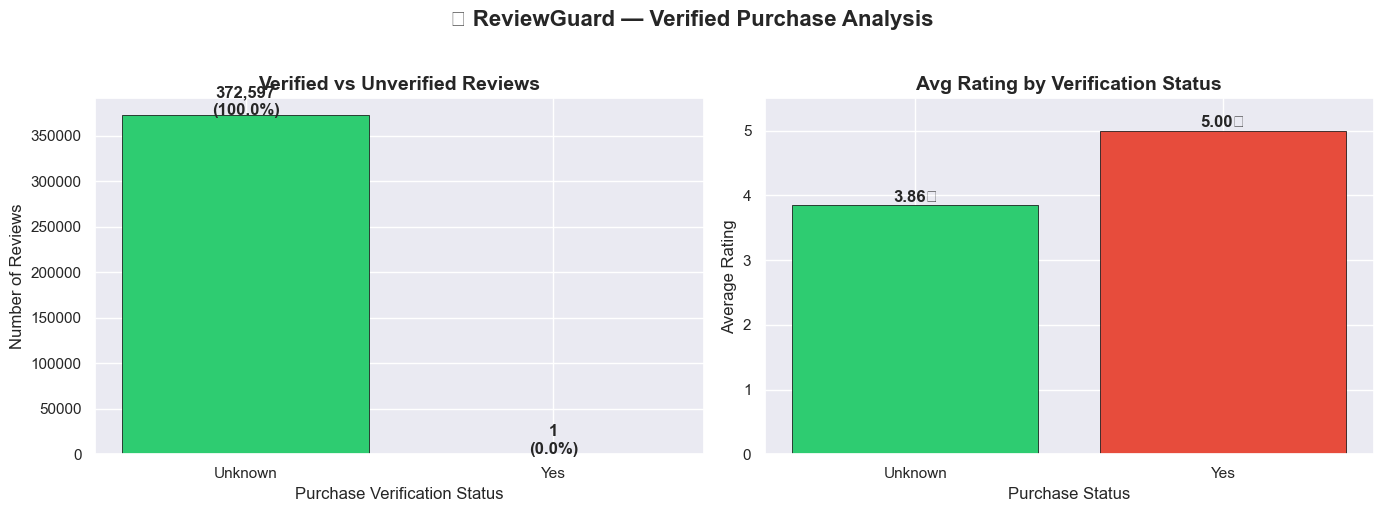

✅ Chart saved: outputs/charts/03_verified_analysis.png


In [10]:
# ── CHART 3: Verified vs Unverified Reviews ───────────────────────────────────

verified_counts = df["verified_purchase"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_v = ["#2ecc71", "#e74c3c", "#95a5a6"]
axes[0].bar(
    verified_counts.index.astype(str),
    verified_counts.values,
    color=colors_v[:len(verified_counts)],
    edgecolor="black",
    linewidth=0.5
)
axes[0].set_title("Verified vs Unverified Reviews",
                   fontsize=14, fontweight="bold")
axes[0].set_xlabel("Purchase Verification Status")
axes[0].set_ylabel("Number of Reviews")
for i, (status, count) in enumerate(verified_counts.items()):
    axes[0].text(
        i, count + 500,
        f"{count:,}\n({count/len(df)*100:.1f}%)",
        ha="center",
        fontweight="bold"
    )

# Avg rating by verified status
avg_by_verified = df.groupby("verified_purchase")["rating"].mean()
axes[1].bar(
    avg_by_verified.index.astype(str),
    avg_by_verified.values,
    color=colors_v[:len(avg_by_verified)],
    edgecolor="black",
    linewidth=0.5
)
axes[1].set_title("Avg Rating by Verification Status",
                   fontsize=14, fontweight="bold")
axes[1].set_xlabel("Purchase Status")
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(0, 5.5)
for i, (status, avg) in enumerate(avg_by_verified.items()):
    axes[1].text(i, avg + 0.05, f"{avg:.2f}⭐",
                 ha="center", fontweight="bold")

plt.suptitle("🔍 ReviewGuard — Verified Purchase Analysis",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/charts/03_verified_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved: outputs/charts/03_verified_analysis.png")

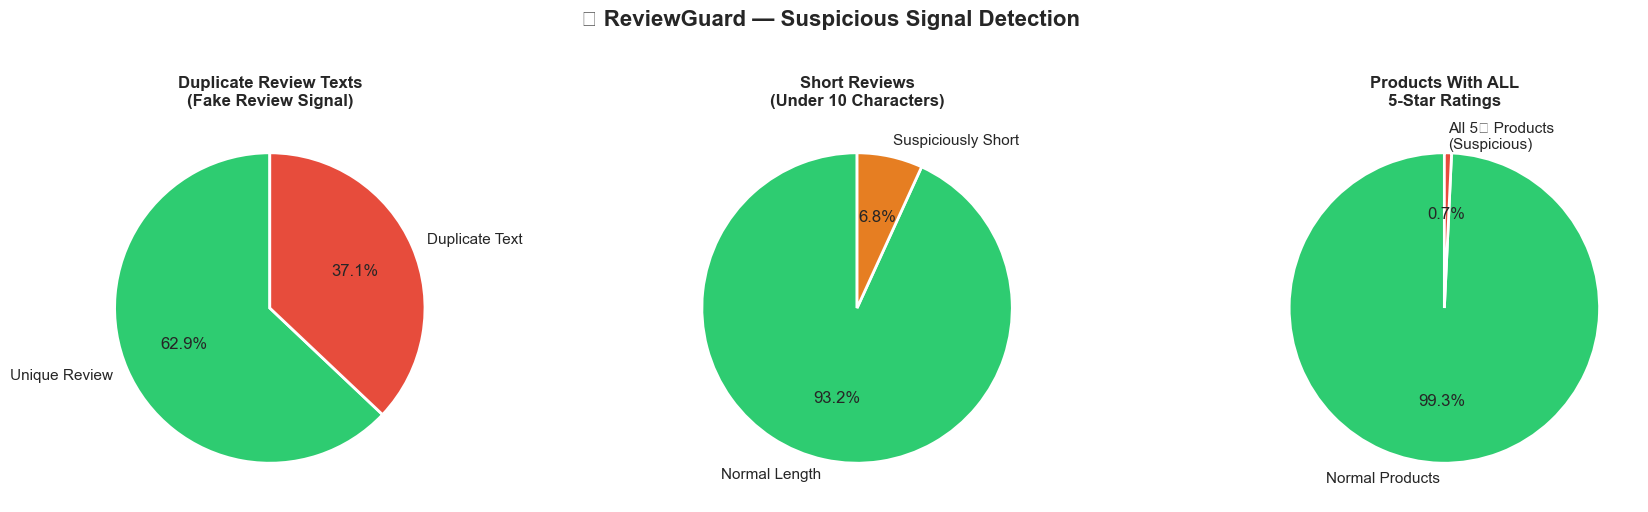

✅ Chart saved: outputs/charts/04_suspicious_signals.png

📊 Suspicious Signals Summary:
   Duplicate review texts  : 234,529
   Short reviews (<10 chars): 25,435
   All-5-star products      : 43


In [11]:
# ── CHART 4: Suspicious Review Signals ───────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 4A: Duplicate review text flag
dup_counts = df["is_duplicate_text"].value_counts()
labels_dup = ["Unique Review", "Duplicate Text"]
colors_dup = ["#2ecc71", "#e74c3c"]
axes[0].pie(
    dup_counts.values,
    labels=labels_dup,
    autopct="%1.1f%%",
    colors=colors_dup,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Duplicate Review Texts\n(Fake Review Signal)",
                   fontsize=12, fontweight="bold")

# Chart 4B: Short review flag
short_counts = df["is_short_review"].value_counts()
labels_short = ["Normal Length", "Suspiciously Short"]
axes[1].pie(
    short_counts.values,
    labels=labels_short,
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e67e22"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Short Reviews\n(Under 10 Characters)",
                   fontsize=12, fontweight="bold")

# Chart 4C: All 5-star products
total_products = df["product_id"].nunique()
all_five_star  = 43
normal_products = total_products - all_five_star
axes[2].pie(
    [normal_products, all_five_star],
    labels=["Normal Products", "All 5★ Products\n(Suspicious)"],
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[2].set_title("Products With ALL\n5-Star Ratings",
                   fontsize=12, fontweight="bold")

plt.suptitle("🚨 ReviewGuard — Suspicious Signal Detection",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/charts/04_suspicious_signals.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Chart saved: outputs/charts/04_suspicious_signals.png")
print(f"\n📊 Suspicious Signals Summary:")
print(f"   Duplicate review texts  : {df['is_duplicate_text'].sum():,}")
print(f"   Short reviews (<10 chars): {df['is_short_review'].sum():,}")
print(f"   All-5-star products      : 43")

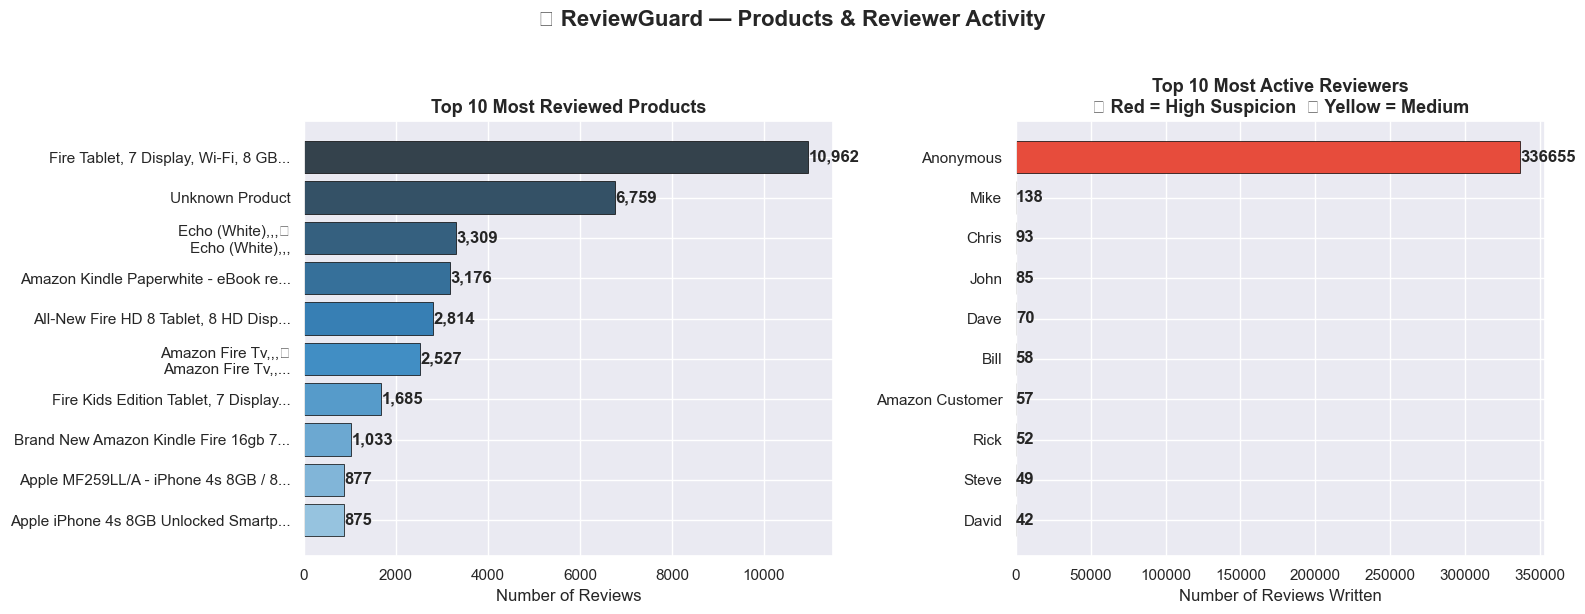

✅ Chart saved: outputs/charts/05_top_products_reviewers.png


In [12]:
# ── CHART 5: Top Products and Reviewers ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 5A: Top 10 most reviewed products
top_products = (
    df.groupby("product_name")["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)
top_products.index = [
    name[:35] + "..." if len(str(name)) > 35 else str(name)
    for name in top_products.index
]
axes[0].barh(
    top_products.index[::-1],
    top_products.values[::-1],
    color=sns.color_palette("Blues_d", 10),
    edgecolor="black",
    linewidth=0.5
)
axes[0].set_title("Top 10 Most Reviewed Products",
                   fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Reviews")
for i, val in enumerate(top_products.values[::-1]):
    axes[0].text(val + 5, i, f"{val:,}", va="center", fontweight="bold")

# Chart 5B: Top 10 most active reviewers
top_reviewers = (
    df.groupby("reviewer_name")["product_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)
colors_rev = [
    "#e74c3c" if count > 10 else "#f39c12" if count > 5 else "#2ecc71"
    for count in top_reviewers.values
]
axes[1].barh(
    top_reviewers.index[::-1],
    top_reviewers.values[::-1],
    color=colors_rev[::-1],
    edgecolor="black",
    linewidth=0.5
)
axes[1].set_title("Top 10 Most Active Reviewers\n🔴 Red = High Suspicion  🟡 Yellow = Medium",
                   fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Reviews Written")
for i, val in enumerate(top_reviewers.values[::-1]):
    axes[1].text(val + 0.1, i, str(val), va="center", fontweight="bold")

plt.suptitle("📊 ReviewGuard — Products & Reviewer Activity",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/charts/05_top_products_reviewers.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved: outputs/charts/05_top_products_reviewers.png")

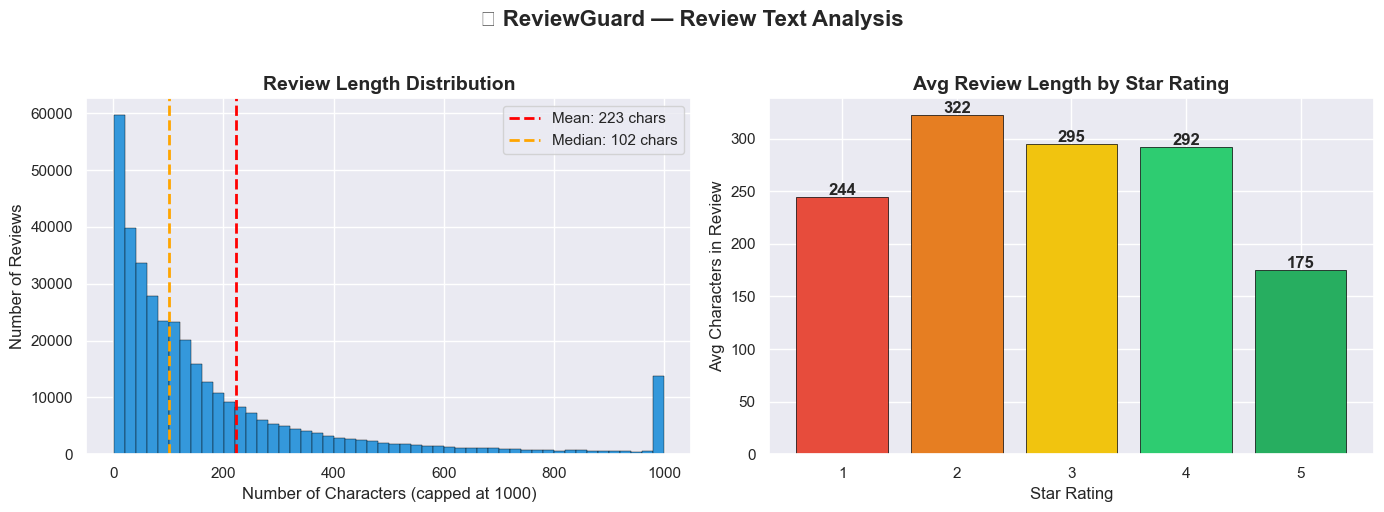

✅ Chart saved: outputs/charts/06_review_length.png

📊 Key Insight:
   Average review length : 223 characters
   Median review length  : 102 characters
   Very short (<10 chars): 25,435 reviews


In [13]:
# ── CHART 6: Review Length Analysis ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 6A: Review length histogram
axes[0].hist(
    df["review_length"].clip(upper=1000),
    bins=50,
    color="#3498db",
    edgecolor="black",
    linewidth=0.3
)
axes[0].axvline(
    df["review_length"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df['review_length'].mean():.0f} chars"
)
axes[0].axvline(
    df["review_length"].median(),
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Median: {df['review_length'].median():.0f} chars"
)
axes[0].set_title("Review Length Distribution",
                   fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Characters (capped at 1000)")
axes[0].set_ylabel("Number of Reviews")
axes[0].legend()

# Chart 6B: Avg review length by star rating
avg_len = df.groupby("rating")["review_length"].mean()
axes[1].bar(
    avg_len.index.astype(str),
    avg_len.values,
    color=colors_rating,
    edgecolor="black",
    linewidth=0.5
)
axes[1].set_title("Avg Review Length by Star Rating",
                   fontsize=14, fontweight="bold")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Avg Characters in Review")
for i, (rating, avg) in enumerate(avg_len.items()):
    axes[1].text(i, avg + 2, f"{avg:.0f}", ha="center", fontweight="bold")

plt.suptitle("📝 ReviewGuard — Review Text Analysis",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/charts/06_review_length.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved: outputs/charts/06_review_length.png")
print(f"\n📊 Key Insight:")
print(f"   Average review length : {df['review_length'].mean():.0f} characters")
print(f"   Median review length  : {df['review_length'].median():.0f} characters")
print(f"   Very short (<10 chars): {df['is_short_review'].sum():,} reviews")

In [14]:
# ── PHASE 1 FINAL SUMMARY ─────────────────────────────────────────────────────

print("=" * 55)
print("  ReviewGuard — Phase 1 Complete!")
print("=" * 55)

print(f"""
📦 DATASET SUMMARY:
   Total Reviews         : {len(df):,}
   Unique Products       : {df['product_id'].nunique():,}
   Unique Reviewers      : {df['reviewer_id'].nunique():,}
   Average Rating        : {df['rating'].mean():.2f} ⭐

⭐ RATING BREAKDOWN:
   5★ Reviews : {len(df[df['rating']==5]):,} ({len(df[df['rating']==5])/len(df)*100:.1f}%)
   4★ Reviews : {len(df[df['rating']==4]):,} ({len(df[df['rating']==4])/len(df)*100:.1f}%)
   3★ Reviews : {len(df[df['rating']==3]):,} ({len(df[df['rating']==3])/len(df)*100:.1f}%)
   2★ Reviews : {len(df[df['rating']==2]):,} ({len(df[df['rating']==2])/len(df)*100:.1f}%)
   1★ Reviews : {len(df[df['rating']==1]):,} ({len(df[df['rating']==1])/len(df)*100:.1f}%)

🚨 SUSPICIOUS SIGNALS FOUND:
   Duplicate review texts   : {df['is_duplicate_text'].sum():,}
   Short reviews (<10 chars): {df['is_short_review'].sum():,}
   High volume reviewers    : 141
   All-5-star products      : 43

📊 CHARTS SAVED:
   ✅ outputs/charts/01_data_sources.png
   ✅ outputs/charts/02_rating_distribution.png
   ✅ outputs/charts/03_verified_analysis.png
   ✅ outputs/charts/04_suspicious_signals.png
   ✅ outputs/charts/05_top_products_reviewers.png
   ✅ outputs/charts/06_review_length.png

🚀 Ready for Phase 2: Feature Engineering!
   We will now extract ML features from:
   - Review text patterns
   - Reviewer behavior
   - Rating anomalies
   - Temporal patterns
""")

  ReviewGuard — Phase 1 Complete!

📦 DATASET SUMMARY:
   Total Reviews         : 372,598
   Unique Products       : 5,798
   Unique Reviewers      : 368,411
   Average Rating        : 3.86 ⭐

⭐ RATING BREAKDOWN:
   5★ Reviews : 201,488 (54.1%)
   4★ Reviews : 60,095 (16.1%)
   3★ Reviews : 28,172 (7.6%)
   2★ Reviews : 21,217 (5.7%)
   1★ Reviews : 61,626 (16.5%)

🚨 SUSPICIOUS SIGNALS FOUND:
   Duplicate review texts   : 234,529
   Short reviews (<10 chars): 25,435
   High volume reviewers    : 141
   All-5-star products      : 43

📊 CHARTS SAVED:
   ✅ outputs/charts/01_data_sources.png
   ✅ outputs/charts/02_rating_distribution.png
   ✅ outputs/charts/03_verified_analysis.png
   ✅ outputs/charts/04_suspicious_signals.png
   ✅ outputs/charts/05_top_products_reviewers.png
   ✅ outputs/charts/06_review_length.png

🚀 Ready for Phase 2: Feature Engineering!
   We will now extract ML features from:
   - Review text patterns
   - Reviewer behavior
   - Rating anomalies
   - Temporal patterns